In [8]:
!mv ~/Desktop/Heart_Dataset_Cleaned.csv .

In [9]:
import pandas as pd

# 1. Adım: Finder içine attığımız veri setini okutuyoruz
dosya_adi = 'Heart_Dataset_Cleaned.csv'
df = pd.read_csv(dosya_adi)

# 2. Adım: Hocanın Bölüm A'daki sorularının cevaplarını yazdırıyoruz
print("=== BÖLÜM A: VERİ SETİNİ TANIMA ===")
print(f"Satır sayısı: {df.shape[0]}")
print(f"Sütun sayısı: {df.shape[1]}")
print(f"Tekrar eden satır sayısı: {df.duplicated().sum()}")
print(f"Eksik (boş) hücre sayısı: {df.isnull().sum().sum()}")
print("\n--- Değişken İsimleri ve Türleri ---")
print(df.dtypes)

=== BÖLÜM A: VERİ SETİNİ TANIMA ===
Satır sayısı: 327
Sütun sayısı: 21
Tekrar eden satır sayısı: 0
Eksik (boş) hücre sayısı: 0

--- Değişken İsimleri ve Türleri ---
Age                               object
Gender                            object
Marital status                    object
Occupation / Daily Activities     object
Living situation                  object
Family Heart problems History     object
Family Diabetes History           object
Food habits                       object
Physical activity                 object
Sleep at night                    object
Depression                        object
Smoke or Tobacco                  object
Alcohol                           object
Feel stressed                     object
Height (cm)                      float64
Weight                           float64
BMI                              float64
Blood Pressure                    object
Diabetes                          object
Medicines                         object
Heart patient  

In [10]:
import pandas as pd
import numpy as np

print("=== BÖLÜM B: TANIMLAYICI İSTATİSTİKLER ===\n")

# 1. KRİTİK ADIM: Age (Yaş) sütununu sayısal türe çeviriyoruz (Hata veren değerler olursa boş bırak diyoruz)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# 2. Sayısal değişkenlerin merkezi eğilim (ortalama, medyan) ve yayılım ölçüleri
print("--- Sayısal Değişkenlerin Özeti (Ortalama, Medyan, Min, Max) ---")
# describe() komutu bize ortalama (mean), medyan (%50), standart sapma (std) gibi bilgileri verir.
sayisal_ozet = df.describe().T
print(sayisal_ozet[['count', 'mean', 'std', 'min', '50%', 'max']])

print("\n" + "="*50 + "\n")

# 3. Kategorik Değişkenlerin Özeti (Mod ve Dağılımlar)
print("--- Kategorik Değişkenlerin Özeti (Mod / En Sık Tekrar Edenler) ---")
# Yazı içeren sütunları seçiyoruz
kategorik_sutunlar = df.select_dtypes(include=['object']).columns

for sutun in kategorik_sutunlar:
    print(f"\nDeğişken: {sutun}")
    print(f"En çok tekrar eden değer (Mod): {df[sutun].mode()[0]}")
    print("Frekans Dağılımı:")
    print(df[sutun].value_counts().head(5)) # Çok uzamasın diye en popüler ilk 5 değeri görelim

=== BÖLÜM B: TANIMLAYICI İSTATİSTİKLER ===

--- Sayısal Değişkenlerin Özeti (Ortalama, Medyan, Min, Max) ---
             count        mean        std     min     50%     max
Age            0.0         NaN        NaN     NaN     NaN     NaN
Height (cm)  327.0  163.072783   6.788715  137.20  162.60  182.90
Weight       327.0   67.179205  11.933481   42.00   68.00  103.00
BMI          327.0   25.237401   4.216494   16.51   24.95   42.46


--- Kategorik Değişkenlerin Özeti (Mod / En Sık Tekrar Edenler) ---

Değişken: Gender
En çok tekrar eden değer (Mod): Male
Frekans Dağılımı:
Gender
Male      196
Female    131
Name: count, dtype: int64

Değişken: Marital status
En çok tekrar eden değer (Mod): Married
Frekans Dağılımı:
Marital status
Married          235
Single            62
Widow/Widower     19
Divorced          11
Name: count, dtype: int64

Değişken: Occupation / Daily Activities
En çok tekrar eden değer (Mod): Moderately Active
Frekans Dağılımı:
Occupation / Daily Activities
Moderatel

In [11]:
# Dosyayı orijinal haliyle tekrar okuyup yaş sütununda ne yazdığına bakıyoruz
df_orijinal = pd.read_csv('Heart_Dataset_Cleaned.csv')
print("Yaş sütunundaki benzersiz değerler ve sayıları:")
print(df_orijinal['Age'].value_counts())

Yaş sütunundaki benzersiz değerler ve sayıları:
Age
> 50     131
35–50    109
< 35      87
Name: count, dtype: int64


In [12]:
import pandas as pd

# Veri setini temiz bir şekilde en baştan tekrar okuyoruz
df = pd.read_csv('Heart_Dataset_Cleaned.csv')

print("=== BÖLÜM B: KUSURSUZ TANIMLAYICI İSTATİSTİKLER TABLOLARI ===\n")

print("--- 1. Sayısal Değişkenlerin Merkezi Eğilim ve Yayılım Ölçüleri ---")
# Gerçek sayısal değişkenlerimiz: Boy, Kilo ve BMI
sayisal_ozet = df[['Height (cm)', 'Weight', 'BMI']].describe().T
# Hocaya sunmak için isimleri güzelleştiriyoruz ve sadece gerekli istatistikleri alıyoruz
sayisal_ozet = sayisal_ozet[['mean', '50%', 'std', 'min', 'max']]
sayisal_ozet.columns = ['Ortalama (Mean)', 'Medyan (50%)', 'Standart Sapma', 'En Küçük (Min)', 'En Büyük (Max)']
print(sayisal_ozet.to_string())

print("\n" + "="*60 + "\n")

print("--- 2. Yaş (Age) Değişkeninin Kategorik Dağılımı (Mod) ---")
print(f"Yaş Değişkeninin Modu (En Sık Tekrar Eden): {df['Age'].mode()[0]}")
print("Grup Dağılımları (Frekans):")
print(df['Age'].value_counts())

=== BÖLÜM B: KUSURSUZ TANIMLAYICI İSTATİSTİKLER TABLOLARI ===

--- 1. Sayısal Değişkenlerin Merkezi Eğilim ve Yayılım Ölçüleri ---
             Ortalama (Mean)  Medyan (50%)  Standart Sapma  En Küçük (Min)  En Büyük (Max)
Height (cm)       163.072783        162.60        6.788715          137.20          182.90
Weight             67.179205         68.00       11.933481           42.00          103.00
BMI                25.237401         24.95        4.216494           16.51           42.46


--- 2. Yaş (Age) Değişkeninin Kategorik Dağılımı (Mod) ---
Yaş Değişkeninin Modu (En Sık Tekrar Eden): > 50
Grup Dağılımları (Frekans):
Age
> 50     131
35–50    109
< 35      87
Name: count, dtype: int64


In [13]:
import pandas as pd

# Veriyi okuyoruz
df = pd.read_csv('Heart_Dataset_Cleaned.csv')

print("=== BÖLÜM B: HOCANIN TÜM SORULARINA NOKTA ATIŞI CEVAPLAR ===\n")

# 1. Heart patient sınıf dağılımı, sayısı ve oranı
kalp_hasta_sayisi = df['Heart patient'].value_counts()
kalp_hasta_orani = df['Heart patient'].value_counts(normalize=True) * 100

print(f"-> Veri setinde KALP HASTASI OLAN kişi sayısı: {kalp_hasta_sayisi.get('Yes', 0)}")
print(f"-> Veri setinde kalp hastası OLMAYAN kişi sayısı: {kalp_hasta_sayisi.get('No', 0)}")
print(f"-> Kalp hastası olanların ORANI: %{kalp_hasta_orani.get('Yes', 0):.2f}")
print(f"-> Kalp hastası olmayanların ORANI: %{kalp_hasta_orani.get('No', 0):.2f}\n")

print("-" * 50)

# 2. Kadın ve erkek katılımcı sayıları
cinsiyet_sayisi = df['Gender'].value_counts()
cinsiyet_orani = df['Gender'].value_counts(normalize=True) * 100
print(f"-> Erkek (Male) katılımcı sayısı: {cinsiyet_sayisi.get('Male', 0)} (%{cinsiyet_orani.get('Male', 0):.2f})")
print(f"-> Kadın (Female) katılımcı sayısı: {cinsiyet_sayisi.get('Female', 0)} (%{cinsiyet_orani.get('Female', 0):.2f})\n")

print("-" * 50)

# 3. En yaygın yaş grubu ve kan basıncı kategorisi
print(f"-> En yaygın yaş grubu (Mod): {df['Age'].mode()[0]} ({df['Age'].value_counts().iloc[0]} kişi)")
print(f"-> En yaygın kan basıncı kategorisi (Mod): {df['Blood Pressure'].mode()[0]} ({df['Blood Pressure'].value_counts().iloc[0]} kişi)\n")

print("=" * 50)
print("--- KATEGORİK DEĞİŞKENLERİN FREKANS VE YÜZDE TABLOLARI ---")

kategorik_sutunlar = df.select_dtypes(include=['object']).columns

for sutun in kategorik_sutunlar:
    print(f"\n[ Değişken: {sutun} ]")
    frekans = df[sutun].value_counts()
    yuzde = df[sutun].value_counts(normalize=True) * 100
    
    # İkisini yan yana şık bir tablo yapıyoruz
    tablo = pd.DataFrame({'Frekans (Kişi)': frekans, 'Yüzde (%)': yuzde.round(2)})
    print(tablo)

=== BÖLÜM B: HOCANIN TÜM SORULARINA NOKTA ATIŞI CEVAPLAR ===

-> Veri setinde KALP HASTASI OLAN kişi sayısı: 108
-> Veri setinde kalp hastası OLMAYAN kişi sayısı: 219
-> Kalp hastası olanların ORANI: %33.03
-> Kalp hastası olmayanların ORANI: %66.97

--------------------------------------------------
-> Erkek (Male) katılımcı sayısı: 196 (%59.94)
-> Kadın (Female) katılımcı sayısı: 131 (%40.06)

--------------------------------------------------
-> En yaygın yaş grubu (Mod): > 50 (131 kişi)
-> En yaygın kan basıncı kategorisi (Mod): Normal (122 kişi)

--- KATEGORİK DEĞİŞKENLERİN FREKANS VE YÜZDE TABLOLARI ---

[ Değişken: Age ]
       Frekans (Kişi)  Yüzde (%)
Age                             
> 50              131      40.06
35–50             109      33.33
< 35               87      26.61

[ Değişken: Gender ]
        Frekans (Kişi)  Yüzde (%)
Gender                           
Male               196      59.94
Female             131      40.06

[ Değişken: Marital status ]
           

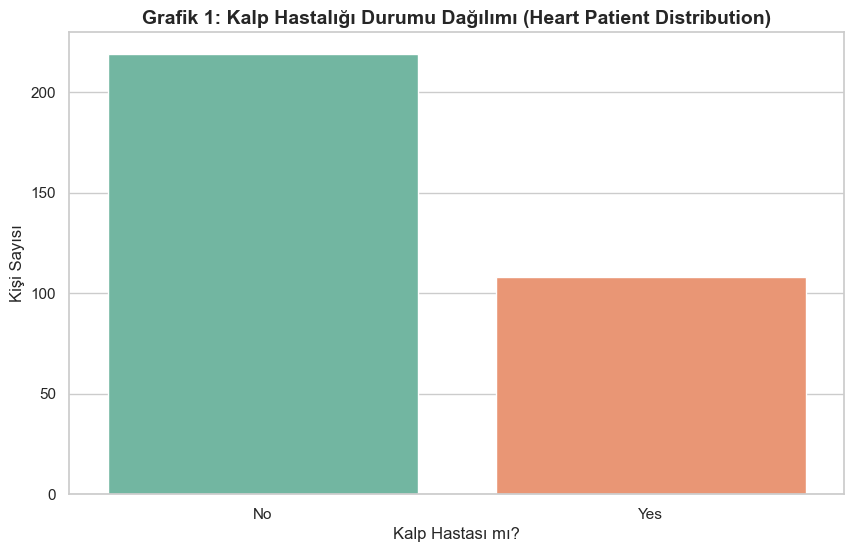

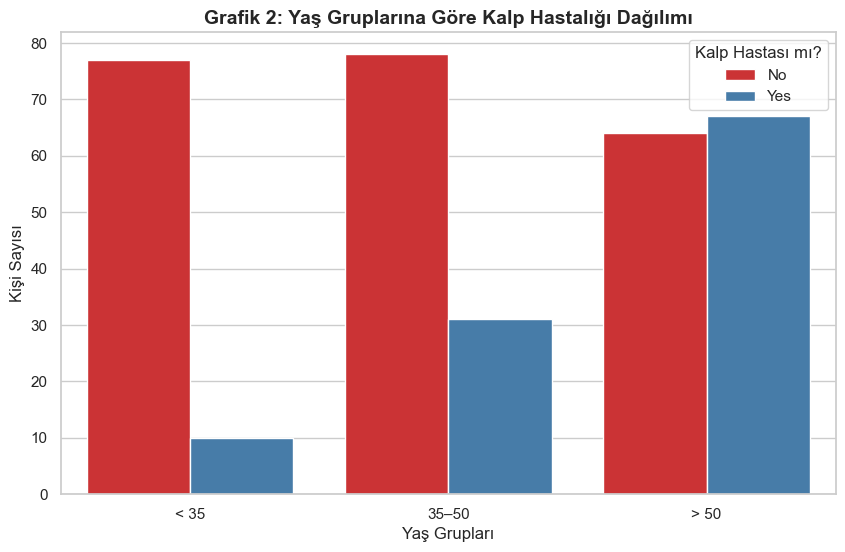

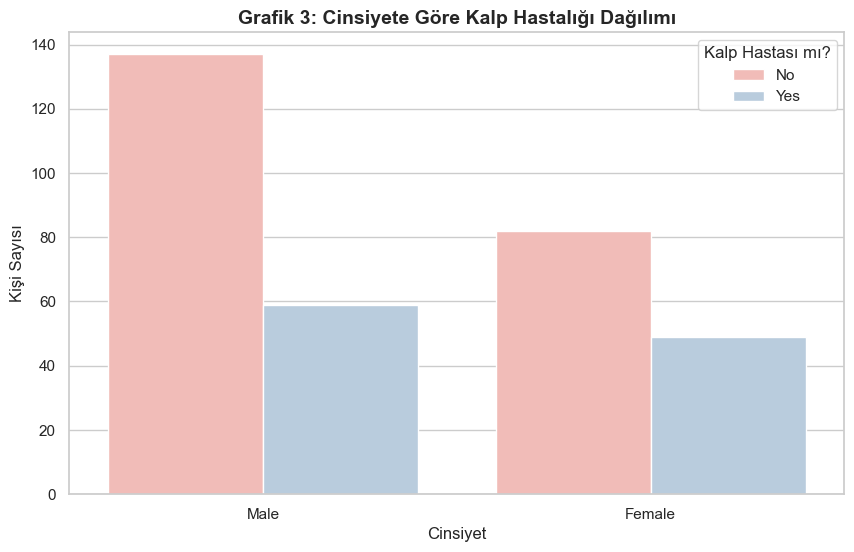

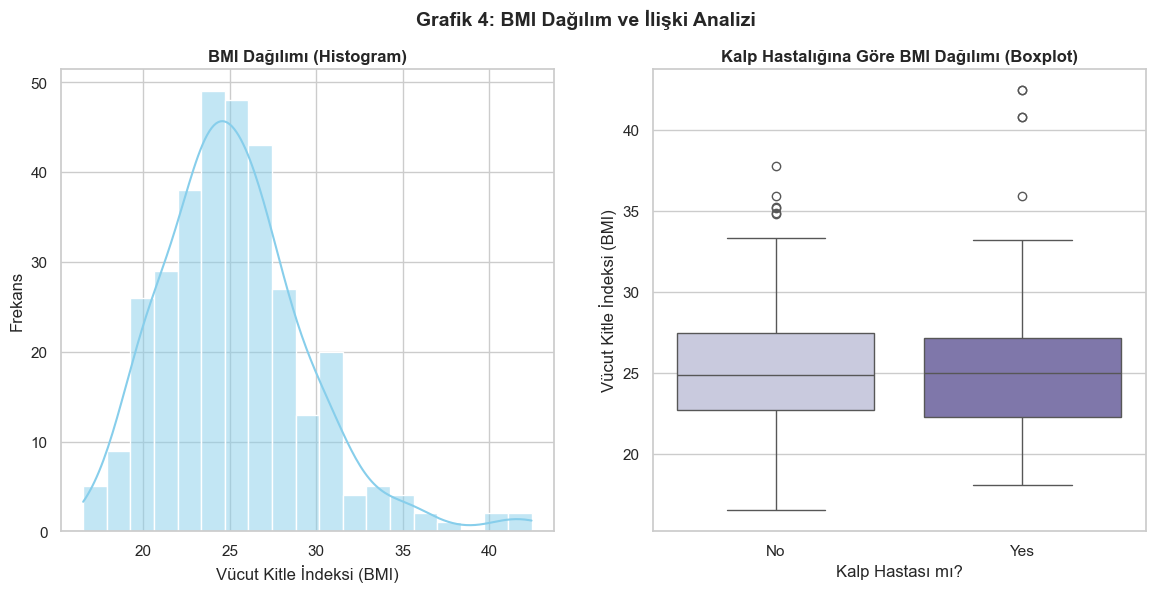

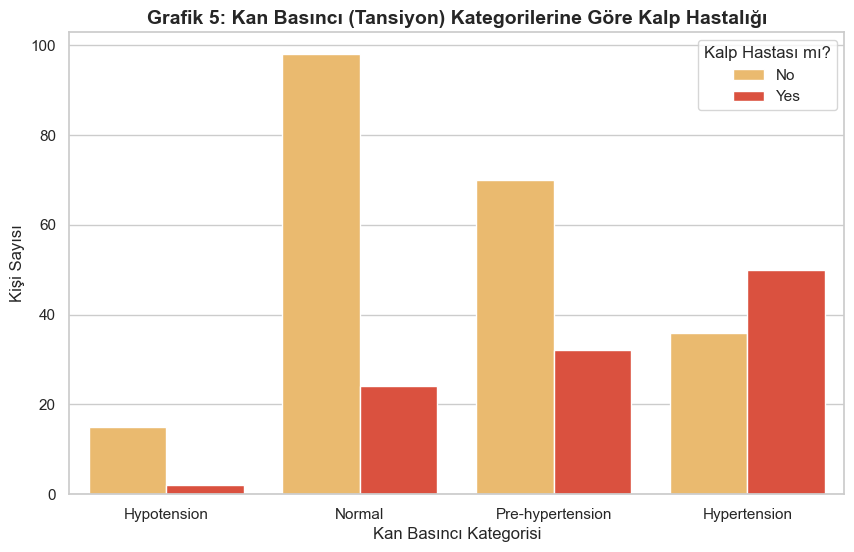

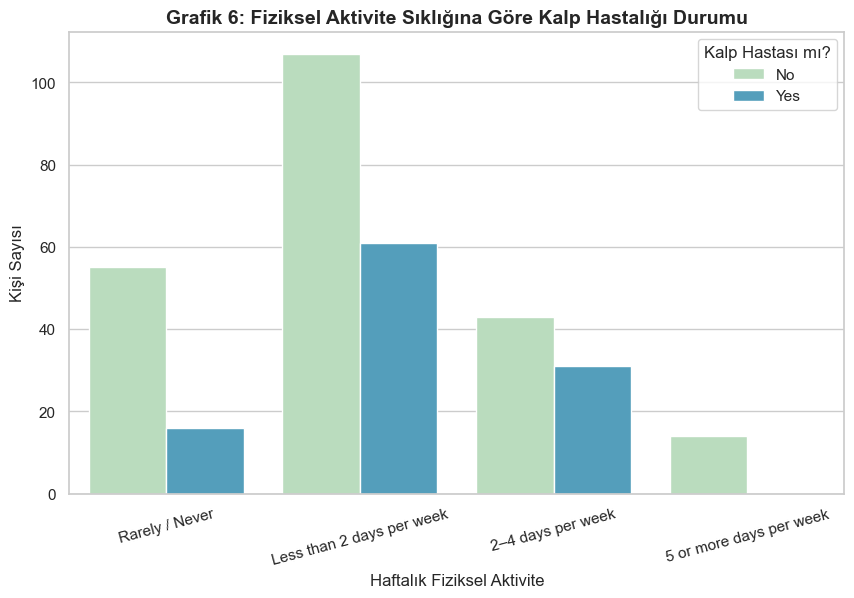

=== ZAFER! TÜM GRAFİKLER KUSURSUZ ŞEKİLDE EKRANDA DURUYOR ===


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Mac ve Jupyter'daki o gereksiz uyarı yazılarını tamamen gizliyoruz
warnings.filterwarnings('ignore')

# Grafiklerin Jupyter ekranında kalıcı olarak belirmesini tetikliyoruz
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# 1. Grafik: Heart Patient Dağılımı (Bar Chart)
plt.figure()
sns.countplot(x='Heart patient', hue='Heart patient', data=df, palette='Set2', legend=False)
plt.title('Grafik 1: Kalp Hastalığı Durumu Dağılımı (Heart Patient Distribution)', fontsize=14, fontweight='bold')
plt.xlabel('Kalp Hastası mı?', fontsize=12)
plt.ylabel('Kişi Sayısı', fontsize=12)
plt.savefig('grafik1_heart_patient.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Grafik: Yaş Grubuna Göre Kalp Hastalığı Dağılımı
plt.figure()
sns.countplot(x='Age', hue='Heart patient', data=df, palette='Set1', order=['< 35', '35–50', '> 50'])
plt.title('Grafik 2: Yaş Gruplarına Göre Kalp Hastalığı Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Yaş Grupları', fontsize=12)
plt.ylabel('Kişi Sayısı', fontsize=12)
plt.legend(title='Kalp Hastası mı?')
plt.savefig('grafik2_age_heart.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Grafik: Cinsiyete Göre Kalp Hastalığı Dağılımı
plt.figure()
sns.countplot(x='Gender', hue='Heart patient', data=df, palette='Pastel1')
plt.title('Grafik 3: Cinsiyete Göre Kalp Hastalığı Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Cinsiyet', fontsize=12)
plt.ylabel('Kişi Sayısı', fontsize=12)
plt.legend(title='Kalp Hastası mı?')
plt.savefig('grafik3_gender_heart.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Grafik: BMI Dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['BMI'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('BMI Dağılımı (Histogram)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Vücut Kitle İndeksi (BMI)')
axes[0].set_ylabel('Frekans')

sns.boxplot(x='Heart patient', y='BMI', hue='Heart patient', data=df, ax=axes[1], palette='Purples', legend=False)
axes[1].set_title('Kalp Hastalığına Göre BMI Dağılımı (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kalp Hastası mı?')
axes[1].set_ylabel('Vücut Kitle İndeksi (BMI)')
plt.suptitle('Grafik 4: BMI Dağılım ve İlişki Analizi', fontsize=14, fontweight='bold')
plt.savefig('grafik4_bmi_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Grafik: Blood Pressure ve Heart Patient İlişkisi
plt.figure()
bp_order = ['Hypotension', 'Normal', 'Pre-hypertension', 'Hypertension']
sns.countplot(x='Blood Pressure', hue='Heart patient', data=df, palette='YlOrRd', order=bp_order)
plt.title('Grafik 5: Kan Basıncı (Tansiyon) Kategorilerine Göre Kalp Hastalığı', fontsize=14, fontweight='bold')
plt.xlabel('Kan Basıncı Kategorisi', fontsize=12)
plt.ylabel('Kişi Sayısı', fontsize=12)
plt.legend(title='Kalp Hastası mı?')
plt.savefig('grafik5_blood_pressure_heart.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Grafik: Physical Activity ve Heart Patient İlişkisi
plt.figure()
pa_order = ['Rarely / Never', 'Less than 2 days per week', '2–4 days per week', '5 or more days per week']
sns.countplot(x='Physical activity', hue='Heart patient', data=df, palette='GnBu', order=pa_order)
plt.title('Grafik 6: Fiziksel Aktivite Sıklığına Göre Kalp Hastalığı Durumu', fontsize=14, fontweight='bold')
plt.xlabel('Haftalık Fiziksel Aktivite', fontsize=12)
plt.ylabel('Kişi Sayısı', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Kalp Hastası mı?')
plt.savefig('grafik6_physical_activity_heart.png', dpi=300, bbox_inches='tight')
plt.show()

print("=== ZAFER! TÜM GRAFİKLER KUSURSUZ ŞEKİLDE EKRANDA DURUYOR ===")

In [18]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("=== BÖLÜM D: RISK FAKTÖRLERİ ANALİZİ (EN AZ 8 DEĞİŞKEN) ===\n")

# Karşılaştıracağımız 8 kritik risk faktörü
risk_faktorleri = [
    'Age', 'Gender', 'Blood Pressure', 'Diabetes', 
    'Smoke or Tobacco', 'Alcohol', 'Feel stressed', 'Family Heart problems History'
]

# 1. Kategorik Risk Faktörlerinin Çapraz Tabloları (Yüzdesel Dağılımları ile)
for faktor in risk_faktorleri:
    print(f"\n[ {faktor} vs Heart patient ]")
    # crosstab ile hem sayıları hem de satır bazlı yüzdeleri alıyoruz ki yorumlamak kolay olsun
    capraz_tablo = pd.crosstab(df[faktor], df['Heart patient'])
    yuzde_tablo = pd.crosstab(df[faktor], df['Heart patient'], normalize='index') * 100
    
    # İki tabloyu birleştirip şık gösteriyoruz
    sonuc_tablosu = pd.DataFrame({
        'Kalp Hastası Değil (No)': capraz_tablo['No'],
        'Kalp Hastası (Yes)': capraz_tablo['Yes'],
        'Hasta Olma Oranı (%)': yuzde_tablo['Yes'].round(2)
    })
    print(sonuc_tablosu)
    print("-" * 50)

print("\n" + "="*60 + "\n")

# 2. Sayısal Risk Faktörü: BMI Analizi
print("[ BMI (Vücut Kitle İndeksi) vs Heart patient ]")
bmi_analiz = df.groupby('Heart patient')['BMI'].agg(['count', 'mean', 'median', 'std']).round(2)
bmi_analiz.columns = ['Kişi Sayısı', 'BMI Ortalama', 'BMI Medyan', 'Standart Sapma']
print(bmi_analiz)

=== BÖLÜM D: RISK FAKTÖRLERİ ANALİZİ (EN AZ 8 DEĞİŞKEN) ===


[ Age vs Heart patient ]
       Kalp Hastası Değil (No)  Kalp Hastası (Yes)  Hasta Olma Oranı (%)
Age                                                                     
35–50                       78                  31                 28.44
< 35                        77                  10                 11.49
> 50                        64                  67                 51.15
--------------------------------------------------

[ Gender vs Heart patient ]
        Kalp Hastası Değil (No)  Kalp Hastası (Yes)  Hasta Olma Oranı (%)
Gender                                                                   
Female                       82                  49                  37.4
Male                        137                  59                  30.1
--------------------------------------------------

[ Blood Pressure vs Heart patient ]
                  Kalp Hastası Değil (No)  Kalp Hastası (Yes)  \
Blood Pressure     

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import warnings

# Mac'teki gereksiz sarı uyarı yazılarını susturuyoruz
warnings.filterwarnings('ignore')

# 1. Veri Önişleme (Makine Öğrenmesi İçin Hazırlık)
df = pd.read_csv('Heart_Dataset_Cleaned.csv')

# Kategorik ve Sayısal sütunları ayırt ediyoruz
kategorik_sutunlar = df.select_dtypes(include=['object']).columns
sayisal_sutunlar = ['Height (cm)', 'Weight', 'BMI']

# One-Hot Encoding ile kategorik sütunları sayısal hale getiriyoruz
# (Hocanın isteği üzerine veriyi 0-1 haline çeviriyoruz)
enc = OneHotEncoder(drop='first', sparse_output=False)
kategorik_encoded = enc.fit_transform(df[kategorik_sutunlar])
kategorik_encoded_df = pd.DataFrame(kategorik_encoded, columns=enc.get_feature_names_out(kategorik_sutunlar))

# Sayısal sütunları ölçeklendiriyoruz (Logistic Regression için gerekli)
scaler = StandardScaler()
sayisal_scaled = scaler.fit_transform(df[sayisal_sutunlar])
sayisal_scaled_df = pd.DataFrame(sayisal_scaled, columns=sayisal_sutunlar)

# Temizlenmiş ve tamamen sayısal veri setini birleştiriyoruz
df_final = pd.concat([sayisal_scaled_df, kategorik_encoded_df], axis=1)

# Hedef değişken: 'Heart patient'ı Yes->1, No->0 yapıyoruz
target_col = df_final.columns[df_final.columns.str.contains('Heart patient_Yes')][0]
X = df_final.drop(target_col, axis=1)
y = df_final[target_col]

# 2. Veriyi Eğitim ve Test Seti Olarak Ayırıyoruz (Train %80, Test %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("=== BÖLÜM E: MAKİNE ÖĞRENMESİ MODELLERİ KARŞILAŞTIRMASI ===\n")
print(f"Eğitim Seti Boyutu: {X_train.shape[0]} satır")
print(f"Test Seti Boyutu: {X_test.shape[0]} satır\n")
print("-" * 50)

# 3. Model 1: Logistic Regression
print("\n--- MODEL 1: LOGISTIC REGRESSION ---")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_pred_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print(f"Accuracy (Doğruluk) Skoru: %{accuracy_score(y_test, y_pred_lr)*100:.2f}")
print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred_lr, target_names=['Heart patient: No (0)', 'Heart patient: Yes (1)']))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_pred_prob_lr):.3f}")

print("-" * 50)

# 4. Model 2: Decision Tree (Karar Ağacı)
print("\n--- MODEL 2: DECISION TREE (KARAR AĞACI) ---")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_pred_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print(f"Accuracy (Doğruluk) Skoru: %{accuracy_score(y_test, y_pred_dt)*100:.2f}")
print("Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_test, y_pred_dt, target_names=['Heart patient: No (0)', 'Heart patient: Yes (1)']))
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, y_pred_prob_dt):.3f}")

=== BÖLÜM E: MAKİNE ÖĞRENMESİ MODELLERİ KARŞILAŞTIRMASI ===

Eğitim Seti Boyutu: 261 satır
Test Seti Boyutu: 66 satır

--------------------------------------------------

--- MODEL 1: LOGISTIC REGRESSION ---
Accuracy (Doğruluk) Skoru: %71.21
Sınıflandırma Raporu (Classification Report):
                        precision    recall  f1-score   support

 Heart patient: No (0)       0.73      0.91      0.81        44
Heart patient: Yes (1)       0.64      0.32      0.42        22

              accuracy                           0.71        66
             macro avg       0.68      0.61      0.62        66
          weighted avg       0.70      0.71      0.68        66

ROC-AUC Skoru: 0.790
--------------------------------------------------

--- MODEL 2: DECISION TREE (KARAR AĞACI) ---
Accuracy (Doğruluk) Skoru: %69.70
Sınıflandırma Raporu (Classification Report):
                        precision    recall  f1-score   support

 Heart patient: No (0)       0.71      0.93      0.80        4